In [1]:
# The ever-growning import block
import numpy as np

import pandas as pd
#from sklearn.preprocessing import StandardScaler
#from sklearn.linear_model import LogisticRegression
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import confusion_matrix, accuracy_score
#from sklearn.model_selection import GridSearchCV
#from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Where's the data?
# e.g. C:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\side-work\function_1\observations.csv
data_path = "C:\\_Source\\Imperial-ML-AI-Live\\Capstone\\imperial-capstone\\side-work\\function_1"
data_filename = "observations.csv"
full_data_path = data_path + "\\" + data_filename

In [3]:
# Basic data load
print("Loading data from: " + full_data_path)
data = pd.read_csv(full_data_path)

Loading data from: C:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\side-work\function_1\observations.csv


In [4]:
# Column inspection
columns = data.columns
print("Columns: ", columns)

Columns:  Index(['observation_id', 'source_round', 'x1', 'x2', 'y'], dtype='str')


In [5]:
# Where we pray for good data, aka checking for nulls
print (data.isna().sum())

observation_id    0
source_round      0
x1                0
x2                0
y                 0
dtype: int64


In [6]:
# Splitting our data into inputs X and outputs y
output_column = "y"
input_columns = ["x1", "x2"]

#print("Input columns: ", input_columns)
#print("Output column: ", output_column)

X = data[input_columns]
y = data[output_column]

#print("The inputs are given by :")
#print(X.head())
#print("The outputs are given by :")
#print(y[:5])


In [7]:
# Ok, here is where we go into more problem-specific territory. 
# We are approaching this as primarily a Bayesian optimization problem where we need to balance exploration and exploitation. 
# We will use a Gaussian Process to model the underlying function and then use an acquisition function to decide where to sample next.
# But first, let's visualize the data to get a better understanding of the underlying function.



Exact zeros: 0 (included on the left; omitted from the log view).
The dotted lines mark zero on the left and the near-zero boundary on the right.


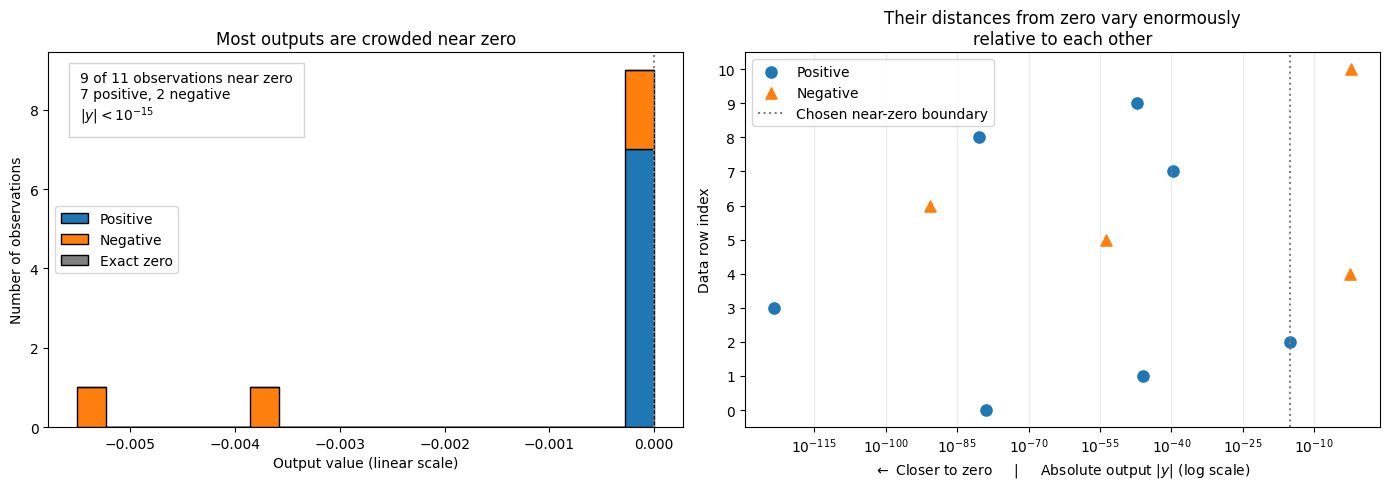

In [8]:
# Two views: how close the outputs are to zero, and how their magnitudes differ.
# This boundary describes the plot; it is not a rule for rounding outputs to zero.
near_zero_exponent = -15
near_zero_limit = 10.0 ** near_zero_exponent
near_zero_count = (y.abs() < near_zero_limit).sum()
near_zero_positive_count = ((y > 0) & (y < near_zero_limit)).sum()
near_zero_negative_count = ((y < 0) & (y > -near_zero_limit)).sum()
zero_count = (y == 0).sum()

fig, (linear_ax, log_ax) = plt.subplots(1, 2, figsize=(14, 5))

# Use shared bins and stack the counts by sign: a bin crossing zero can contain both.
# Include exact zeros as a separate group so every observation remains in this view.
linear_ax.hist(
    [y[y > 0], y[y < 0], y[y == 0]],
    bins=20, stacked=True, edgecolor="black",
    color=["tab:blue", "tab:orange", "grey"],
    label=["Positive", "Negative", "Exact zero"],
)
linear_ax.legend(loc="center left")
linear_ax.axvline(0, color="grey", linestyle=":")
linear_ax.set_title("Most outputs are crowded near zero")
linear_ax.set_xlabel("Output value (linear scale)")
linear_ax.set_ylabel("Number of observations")
linear_ax.text(
    0.05, 0.95,
    f"{near_zero_count} of {len(y)} observations near zero\n"
    + f"{near_zero_positive_count} positive, {near_zero_negative_count} negative"
    + (f", {zero_count} exact zero" if zero_count else "")
    + "\n" + rf"$|y| < 10^{{{near_zero_exponent}}}$",
    transform=linear_ax.transAxes, va="top",
    bbox=dict(facecolor="white", edgecolor="lightgrey", pad=8),
)

# A logarithmic axis cannot include zero. Absolute values give distance from zero;
# colour and marker shape retain the original sign. Each row is one observation.
for label, outputs, colour, marker in [
    ("Positive", y[y > 0], "tab:blue", "o"),
    ("Negative", y[y < 0], "tab:orange", "^"),
]:
    log_ax.scatter(
        outputs.abs(), outputs.index,
        color=colour, marker=marker, s=65, label=label,
    )

# Plot the magnitudes themselves; the axis supplies the logarithmic spacing
# and labels them as powers of ten rather than showing their logarithms.
log_ax.set_xscale("log")
log_ax.axvline(
    near_zero_limit, color="grey", linestyle=":",
    label="Chosen near-zero boundary",
)
log_ax.set_title("Their distances from zero vary enormously\nrelative to each other")
log_ax.set_xlabel(r"$\leftarrow$ Closer to zero     |     Absolute output $|y|$ (log scale)")
log_ax.set_ylabel("Data row index")
log_ax.set_yticks(y.index)
log_ax.grid(axis="x", alpha=0.25)
log_ax.legend()

print(f"Exact zeros: {zero_count} (included on the left; omitted from the log view).")
print("The dotted lines mark zero on the left and the near-zero boundary on the right.")
plt.tight_layout()
plt.show()
